In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path
from sklearn.decomposition import PCA

In [ ]:
# Paths
RESULTS_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results")
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUTS_DIR = RESULTS_DIR / "outputs"
EDA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
#Reload datasets
IMAGE_SIZE = 120
BATCH_SIZE = 32
DATASET_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/train_images"

dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = dataset.class_names
print("Classes:", class_names)


Found 14990 files belonging to 8 classes.
Classes: ['bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [5]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

/tmp/ipython-input-4025091121.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [ ]:
feature_list = []
label_list = []
batch_count = 0

for images, labels in dataset.take(5):  
    # Apply normalization manually (same as Members 4 & 5)
    normalized_images = tf.cast(images, tf.float32) / 255.0

    # Extract features
    embeddings = base_model(normalized_images)
    feature_list.append(embeddings.numpy())
    label_list.append(labels.numpy())

    batch_count += 1
    print(f"Processed batch {batch_count}/5")

X = np.concatenate(feature_list, axis=0)
y = np.concatenate(label_list, axis=0)
print(f" Embeddings extracted! Shape: {X.shape}")


Processed batch 1/5
Processed batch 2/5
Processed batch 3/5
Processed batch 4/5
Processed batch 5/5
 Embeddings extracted! Shape: (160, 1280)


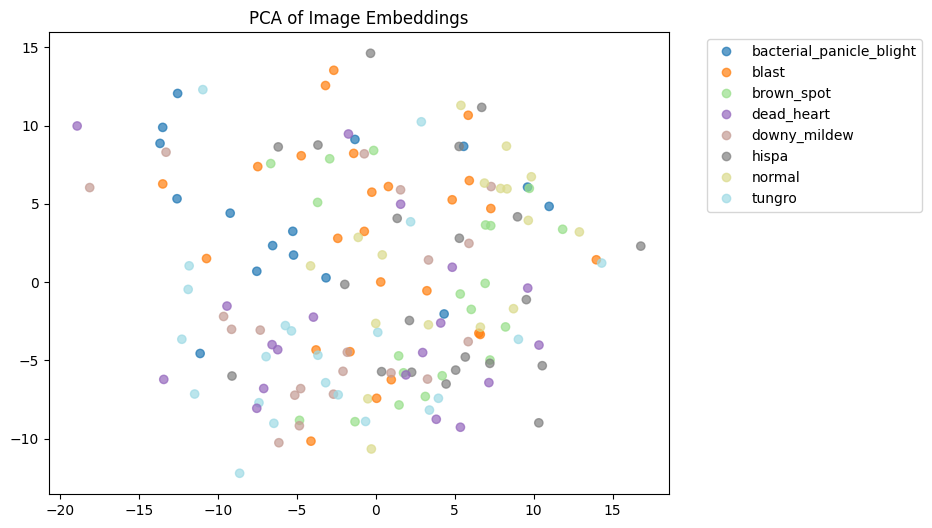

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab20", alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA of Image Embeddings")
plt.savefig(EDA_DIR / "embedding_pca.png", dpi=150)
plt.show()

In [ ]:
# Save Report
    "technique": "Feature Engineering with Embeddings",
    "embedding_model": "MobileNetV2 (pretrained on ImageNet)",
    "dimension_reduction": "PCA (2D only)",
    "samples_used": int(X.shape[0]),
    "status": "completed"
}
with open(OUTPUTS_DIR / "embedding_report.json", "w") as f:
    json.dump(report, f, indent=2)